In [147]:
# For data manipulation
import numpy as np 
import pandas as pd 

# For data visualization
import matplotlib.pyplot as plt 

# Ingore the warnings
import warnings
warnings.filterwarnings('ignore')

# DL Libraries
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.utils import image_dataset_from_directory

# Other libraries
import os
import random

In [ ]:
# Load the image dataset from the directory using utils
# ds = image_dataset_from_directory('E:\DataScience Codanics\Kaggle\LAPTOP Items classification\PC Part Classification\Data')

train_ds, temp_ds = keras.utils.image_dataset_from_directory(
    directory='datasets/cat-and-dog/test_set/test_set',
    validation_split=0.3,
    subset='both',
    seed=42,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256),
)

temp_batches = tensorflow.data.experimental.cardinality(temp_ds)

val_size = temp_batches // 2

val_ds = temp_ds.take(val_size)

test_ds = temp_ds.skip(val_size)

Found 2023 files belonging to 2 classes.
Using 1417 files for training.
Using 606 files for validation.


In [149]:
# Creating a function to visualize the images

def visualize_images(path, num_images=5):

    # Get a list of image filenames
    image_filenames = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]

    if not image_filenames:
        raise ValueError("No images found in the specified path")

    # Select random images
    selected_images = random.sample(image_filenames, min(num_images, len(image_filenames)))

    # Create a figure and axes
    fig, axes = plt.subplots(1, num_images, figsize=(20, 4), facecolor='white')

    # Display each image
    for i, image_filename in enumerate(selected_images):
        # Load image
        image_path = os.path.join(path, image_filename)
        image = plt.imread(image_path)

        # Display image
        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(image_filename)  # Set image filename as title

    # Adjust layout and display
    plt.tight_layout()
    plt.show()

CATS


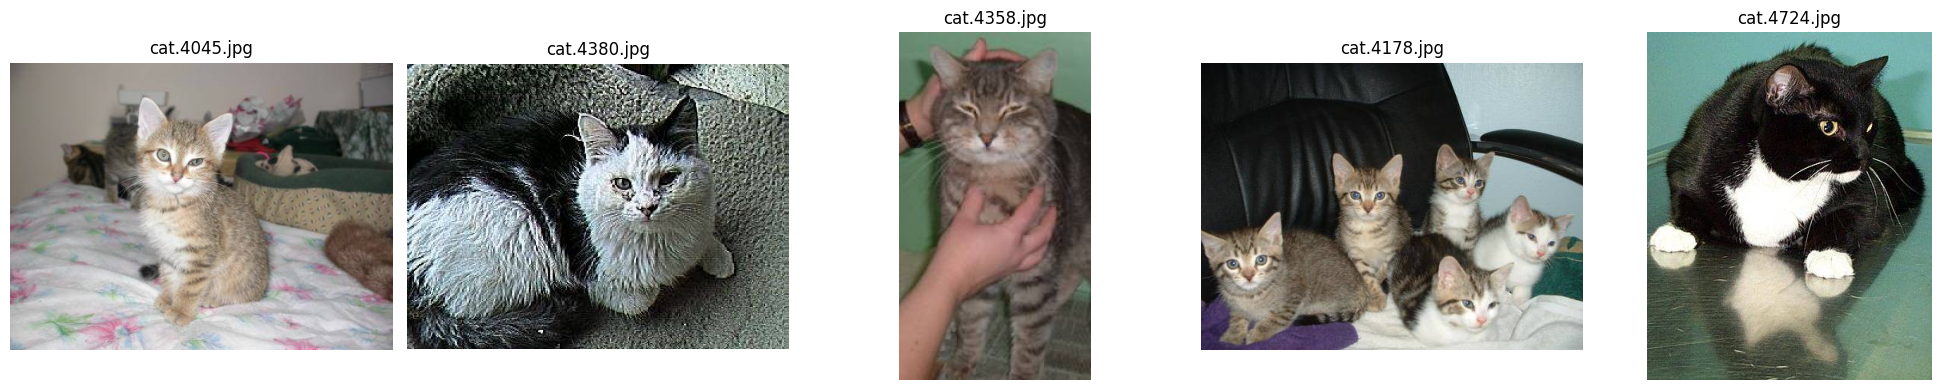

DOGS


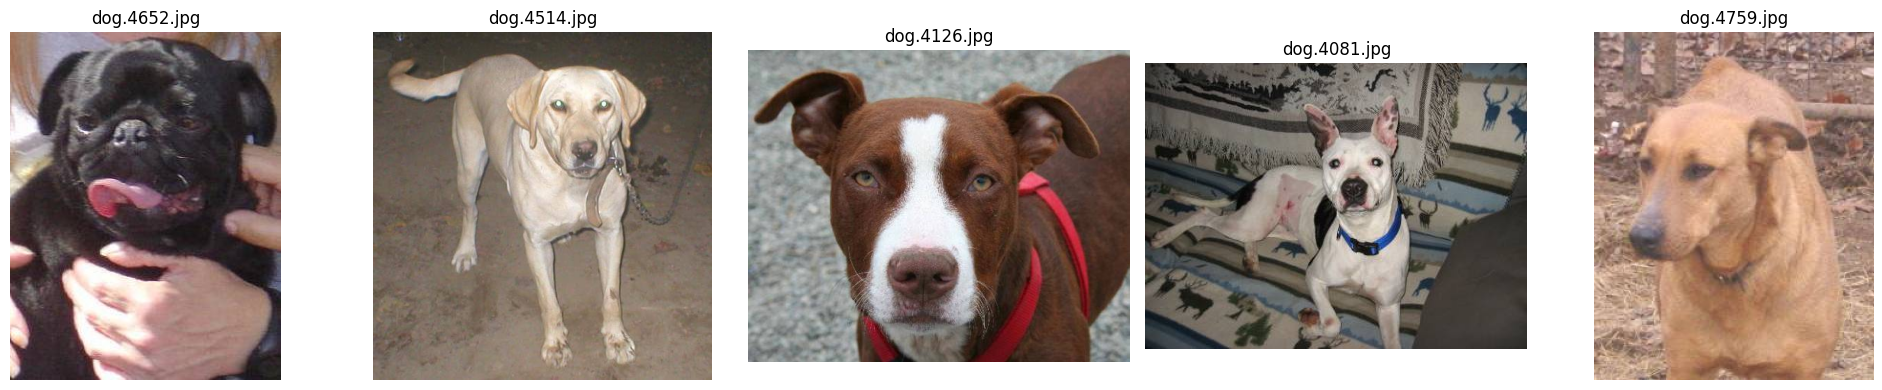

In [150]:
# Extrating the class labels
classes = train_ds.class_names

# Iterating through each class to plot its images
for label in classes:
    
    # Specify the path containing the images to visualize
    path_to_visualize = f"datasets/cat-and-dog/test_set/test_set/{label}"

    # Visualize 5 random images
    print(label.upper())
    visualize_images(path_to_visualize, num_images=5)

In [ ]:
model = Sequential()

model.add(Conv2D(64, kernel_size=(3,3),activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(128, kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))


model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 125, 125, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 492032)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │    62,980,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,066,241 (240.58 MB)

 Trainable params: 63,066,241 (240.58 MB)

 Non-trainable params: 0 (0.00 B)

In [152]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(train_ds, batch_size=32, epochs=5, validation_data=val_ds, verbose=1)

Epoch 1/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 527ms/step - accuracy: 0.5025 - loss: 59.4195 - val_accuracy: 0.5208 - val_loss: 0.6921
Epoch 2/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 537ms/step - accuracy: 0.5406 - loss: 0.6798 - val_accuracy: 0.5382 - val_loss: 0.7211
Epoch 3/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 526ms/step - accuracy: 0.6740 - loss: 0.5934 - val_accuracy: 0.5174 - val_loss: 0.7048
Epoch 4/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 24s 522ms/step - accuracy: 0.8031 - loss: 0.4133 - val_accuracy: 0.5174 - val_loss: 1.2806
Epoch 5/5
45/45 ━━━━━━━━━━━━━━━━━━━━ 23s 522ms/step - accuracy: 0.8913 - loss: 0.2497 - val_accuracy: 0.5035 - val_loss: 2.5265


In [153]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5818 - loss: 2.3114
Test Loss: 2.3114
Test Accuracy: 0.5818


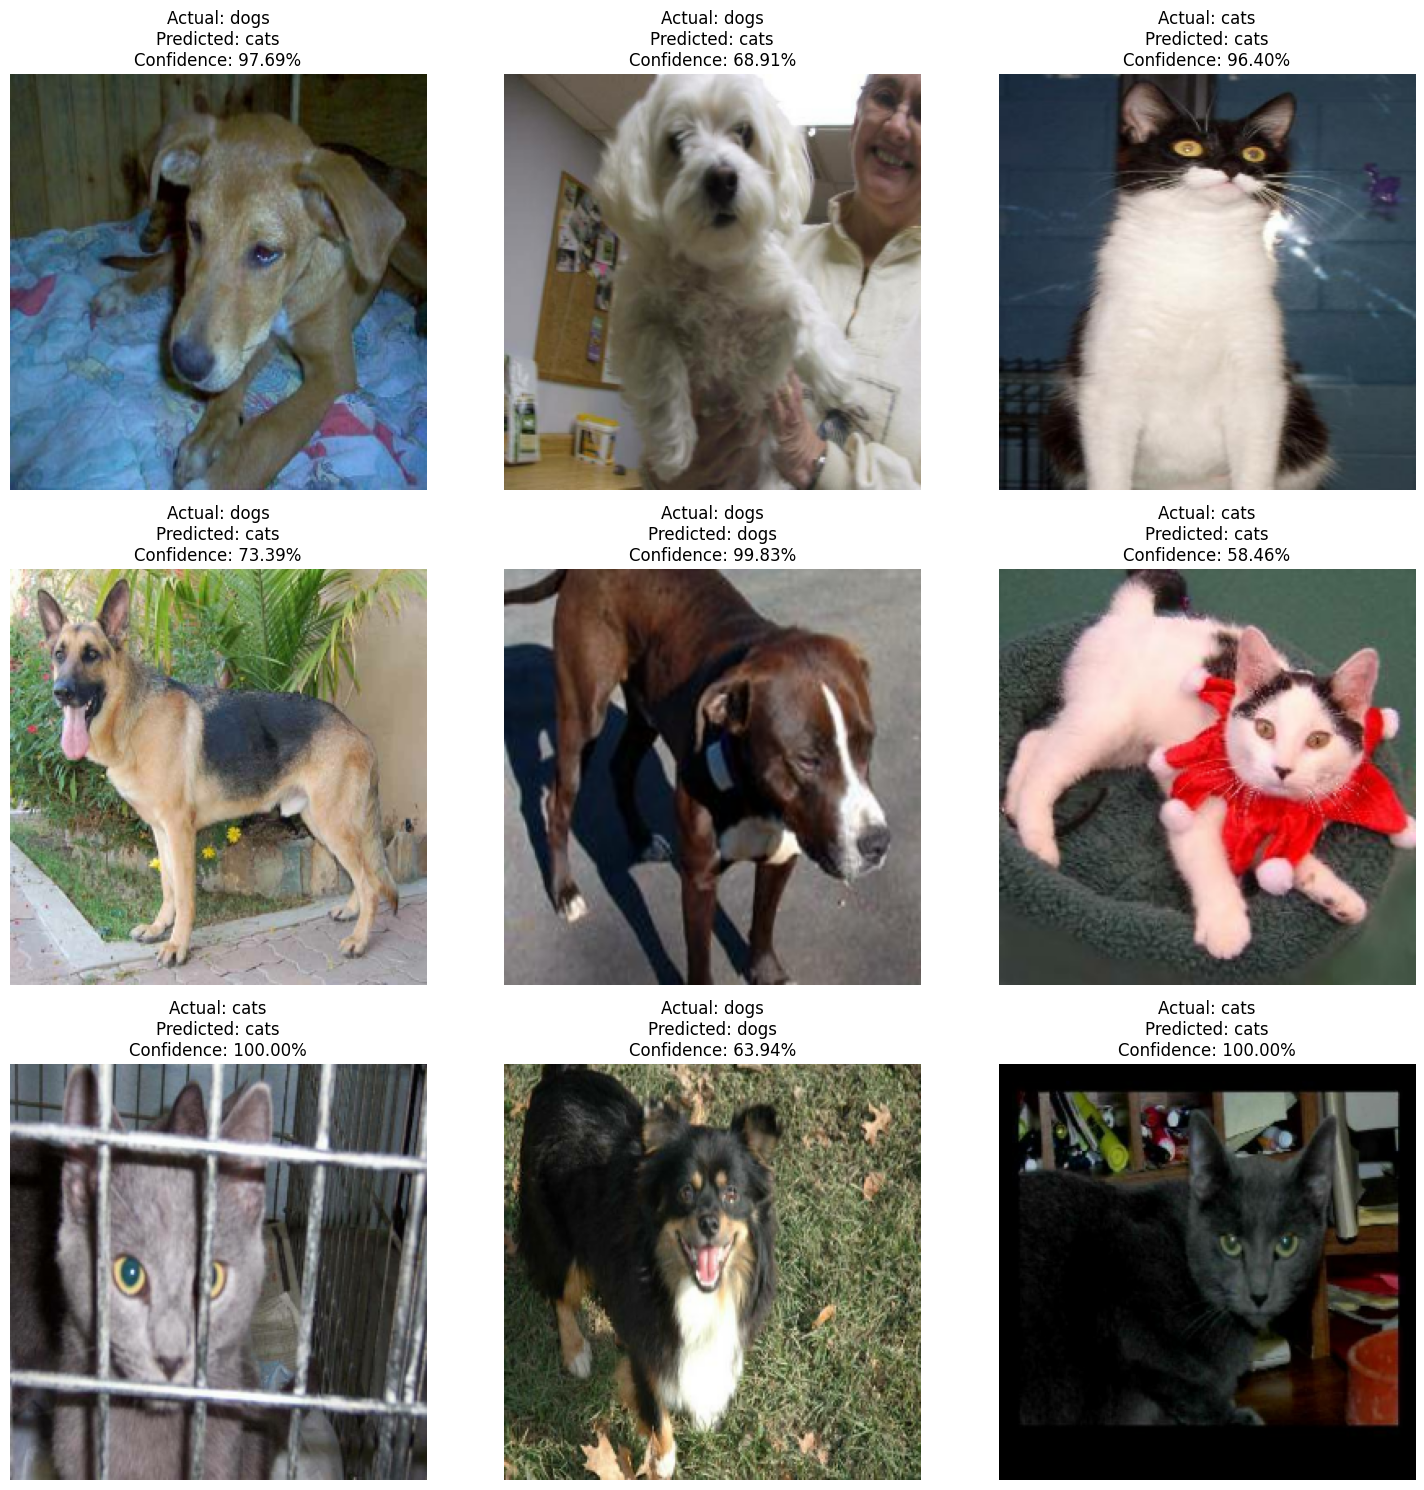

In [154]:
# Get class names
class_names = train_ds.class_names

# Take one batch from test set
for images, labels in test_ds.take(1):

    plt.figure(figsize=(15,15))

    for i in range(9):

        # Select image
        img = images[i]

        # Expand dimensions for prediction
        img_array = tensorflow.expand_dims(img, 0)

        # Predict
        prediction = model.predict(img_array, verbose=0)

        score = prediction[0][0]

        # Convert prediction to class
        predicted_label = 1 if score > 0.5 else 0

        predicted_class = class_names[predicted_label]

        actual_class = class_names[labels[i]]

        confidence = score if score > 0.5 else 1 - score

        # Plot image
        ax = plt.subplot(3,3,i+1)

        plt.imshow(img.numpy().astype("uint8"))

        plt.title(
            f"Actual: {actual_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {confidence*100:.2f}%"
        )

        plt.axis("off")

    plt.tight_layout()

    plt.show()

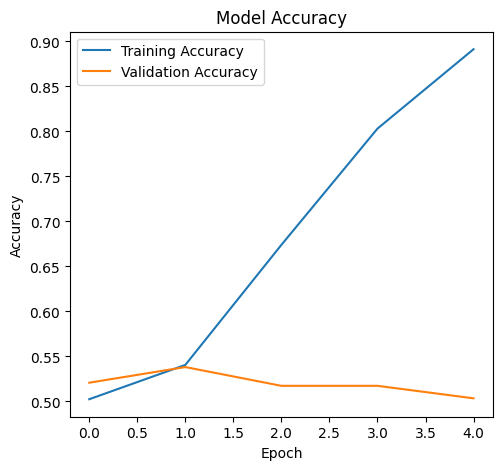

In [155]:
# Accuracy graph

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()